# Modelling data - Version 1
This version includes all variables from the dataset.

<div>
Trabajo Integrador<br>
Maestría en Analítica e Inteligencia de Negocios<br>
Universidad del Valle<br>

</div>

#### Student
Camilo Andrés Jaramillo Tarapues - 2402218 

## Libraries

In [51]:
# Libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error

## Dataset

In [52]:
# Cargar el conjunto de datos
df = pd.read_csv('../../data/out/dataset_final.csv')
df

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.00,28880.74,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.00,29107.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.00,25939.87,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.00,25651.57,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.00,25245.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025-06-30 19:00:00,2025,6,30,19,112.55,1311491.62,9025510.46,2476.26,88117.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48188,2025-06-30 20:00:00,2025,6,30,20,112.55,1316147.03,8848494.08,1550.03,93431.69,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48189,2025-06-30 21:00:00,2025,6,30,21,106.25,1376475.95,8510792.32,0.00,95167.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48190,2025-06-30 22:00:00,2025,6,30,22,105.55,1401097.29,8058142.03,0.00,99156.29,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63


In [3]:
print("Dataset info: ")
print(df.info())

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48192 entries, 0 to 48191
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FECHA_HORA             48192 non-null  object 
 1   YEAR                   48192 non-null  int64  
 2   MONTH                  48192 non-null  int64  
 3   DAY                    48192 non-null  int64  
 4   HORA                   48192 non-null  int64  
 5   PRECIO                 48192 non-null  float64
 6   TERMICA                48192 non-null  float64
 7   HIDRAULICA             48192 non-null  float64
 8   SOLAR                  48192 non-null  float64
 9   COGENERADOR            48192 non-null  float64
 10  EOLICA                 48192 non-null  float64
 11  NIVEL_ENSO             48192 non-null  float64
 12  FUEL_CONS_ACPM         48192 non-null  float64
 13  FUEL_CONS_CARBON       48192 non-null  float64
 14  FUEL_CONS_COMBUSTOLEO  48192 non-null  

In [4]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
FECHA_HORA               0
YEAR                     0
MONTH                    0
DAY                      0
HORA                     0
PRECIO                   0
TERMICA                  0
HIDRAULICA               0
SOLAR                    0
COGENERADOR              0
EOLICA                   0
NIVEL_ENSO               0
FUEL_CONS_ACPM           0
FUEL_CONS_CARBON         0
FUEL_CONS_COMBUSTOLEO    0
FUEL_CONS_CRUDO          0
FUEL_CONS_GAS            0
FUEL_CONS_GAS_NI         0
FUEL_CONS_GLP            0
FUEL_COST_CARBON         0
FUEL_COST_GAS            0
FUEL_COST_GAS_NI         0
FUEL_COST_COMBUSTOLEO    0
IPC_VAR_MOM_PCT          0
IPP_VAR_PN_MOM_PCT       0
IPP_VAR_OI_MOM_PCT       0
dtype: int64


**There are no missing values and all data is numeric, so it is ready to train the models.**

## Scale data

In [53]:
# Define target column 'PRECIO'
TARGET_COLUMN = 'PRECIO'

# Variables that are truly categorical even though they are numerical
categorical_numeric = ["YEAR", "MONTH", "DAY", "HORA", "NIVEL_ENSO"]

# Identify the continuous numerical columns that we do scale
numeric_features = [
    col for col in df.columns 
    if col not in categorical_numeric and col != TARGET_COLUMN and col != 'FECHA_HORA'
]

# Preprocessor: We only scale continuous numerics
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough", categorical_numeric)
    ]
)

## Train, test and split data

Dividing the balanced dataset into two subsets: one to train the model8(70% of the data) and another to evaluate it (remainin2 30%

In [6]:
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar el tamaño de cada conjunto
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 24)
Test set size: (9639, 24)


## Baseline Models

In [7]:
# Baseline models evaluation with multiple metrics

# Define dictionary of regression models
random_state=42

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),  # may be slower on large datasets
    "KNN": KNeighborsRegressor(),  # may be slower on large datasets
}

# Define multiple metrics
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "mse": make_scorer(mean_squared_error),
    "rmse": make_scorer(lambda y, y_pred: mean_squared_error(y, y_pred, squared=False))
}

In [8]:
results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression -0.674345  176.143089   81073.484241  255.868922
Ridge             -0.673436  176.120759   81060.409212  255.836226
Lasso             -0.325634  165.753530   75625.847518  242.202735
ElasticNet         0.185139  145.374287   62001.490904  211.163299
Decision Tree     -8.692514  249.154730  247720.338495  431.537295
Random Forest     -2.352729  192.978591  125518.982163  309.732879
Gradient Boosting -0.639346  162.598554   89007.378341  248.218739
SVR               -0.671078  232.611620  131116.991248  304.197465
KNN               -0.225339  161.433940   77056.569938  242.010131


In [9]:
#                         r2         mae            mse        rmse
#Linear Regression -0.674345  176.143089   81073.484241  255.868922
#Ridge             -0.673436  176.120759   81060.409212  255.836226
#Lasso             -0.325634  165.753530   75625.847518  242.202735
#ElasticNet         0.185139  145.374287   62001.490904  211.163299
#Decision Tree     -3.449350  228.943037  184205.415683  378.558964
#Random Forest     -2.352729  192.978591  125518.982163  309.732879
#Gradient Boosting -0.639346  162.598554   89007.378341  248.218739
#SVR               -0.671078  232.611620  131116.991248  304.197465
#KNN               -0.225339  161.433940   77056.569938  242.010131

### GridSearch CV

In [10]:
# Define hiperparameters
param_grids = {
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "RandomForest": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7]
    }
}

# Define models
models = {
    "ElasticNet": ElasticNet(max_iter=10000, random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [11]:
# Para guardar resultados
best_models = {}
results = {}

for name, model in models.items():
    print("************************************************")
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X, y)
    
    best_models[name] = grid.best_estimator_
    results[name] = {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    }
    print(f"Model: {name}")
    print(f"Best score: {grid.best_score_}")
    print(f"Best params: {grid.best_params_}")
    
results

************************************************
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Model: ElasticNet
Best score: 0.2076746414849791
Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
************************************************
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model: RandomForest
Best score: -2.109574974486729
Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
************************************************
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Model: GradientBoosting
Best score: -0.46319237914950817
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}


{'ElasticNet': {'best_score': 0.2076746414849791,
  'best_params': {'model__alpha': 10, 'model__l1_ratio': 0.9}},
 'RandomForest': {'best_score': -2.109574974486729,
  'best_params': {'model__max_depth': 10,
   'model__min_samples_split': 10,
   'model__n_estimators': 300}},
 'GradientBoosting': {'best_score': -0.46319237914950817,
  'best_params': {'model__learning_rate': 0.1,
   'model__max_depth': 3,
   'model__n_estimators': 500}}}

In [12]:
#************************************************
#Fitting 5 folds for each of 30 candidates, totalling 150 fits
#Model: ElasticNet
#Best score: 0.2076746414849791
#Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
#************************************************
#Fitting 5 folds for each of 36 candidates, totalling 180 fits
#Model: RandomForest
#Best score: -2.109574974486729
#Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
#************************************************
#Fitting 5 folds for each of 27 candidates, totalling 135 fits
#Model: GradientBoosting
#Best score: -0.46319237914950817
#Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}

### Boost models

In [13]:
robust_models = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

In [14]:
robust_results = {}

for name, model in robust_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    robust_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

pd.DataFrame(robust_results).T

,r2,mae,mse,rmse
XGBoost,-0.965013,181.240596,117907.185579,290.594122
LightGBM,-0.734979,161.506282,93543.323013,259.056607
CatBoost,-0.179829,157.462174,80911.380778,233.367902


## Time Series Forecasting

### Splits the training and test sets as a time series

In [15]:
# Separar variables y target
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Usar el índice para cortar: primeras 80% filas = train, últimas 20% filas = test
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 24)
Test set size: (9639, 24)


In [16]:
# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression -1.314511  173.872138   69765.013482  247.290979
Ridge             -1.216505  173.146430   69420.571095  246.192788
Lasso              0.006858  156.563965   63464.525227  222.213720
ElasticNet        -0.139578  163.098969   69464.920229  231.241585
Decision Tree     -0.165435  177.322094  101097.682119  258.480628
Random Forest     -0.142889  168.903260   92962.156461  248.467298
Gradient Boosting -0.098017  160.012782   86994.777105  236.905665
SVR               -1.181558  252.494190  155957.937143  338.512077
KNN               -0.425101  181.107237   84979.339029  256.885555


### Prophet

In [17]:
# Prepare data for Prophet: needs 'ds' (date) and 'y' (target)

df_prophet = df.copy()
df_prophet = df_prophet.drop(columns=["YEAR", "MONTH", "DAY", "HORA"])
df_prophet.head()

,FECHA_HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,FUEL_CONS_ACPM,FUEL_CONS_CARBON,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,72.02,2109637.93,4418103.51,0.0,28880.74,4291.34,1.0,0.0,234788.670155,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,136.71,1864989.80,4548853.97,0.0,29107.37,3511.94,1.0,0.0,234788.670155,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,127.71,1720883.01,4525898.75,0.0,25939.87,2641.90,1.0,0.0,234788.670155,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,127.71,1649014.61,4458645.56,0.0,25651.57,3032.30,1.0,0.0,234788.670155,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,127.71,1711745.36,4279657.90,0.0,25245.37,2514.76,1.0,0.0,234788.670155,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02


10:57:17 - cmdstanpy - INFO - Chain [1] start processing
10:58:34 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Prophet Forecasting Results:
MAE: 266.23, RMSE: 450.33, R2: 0.19


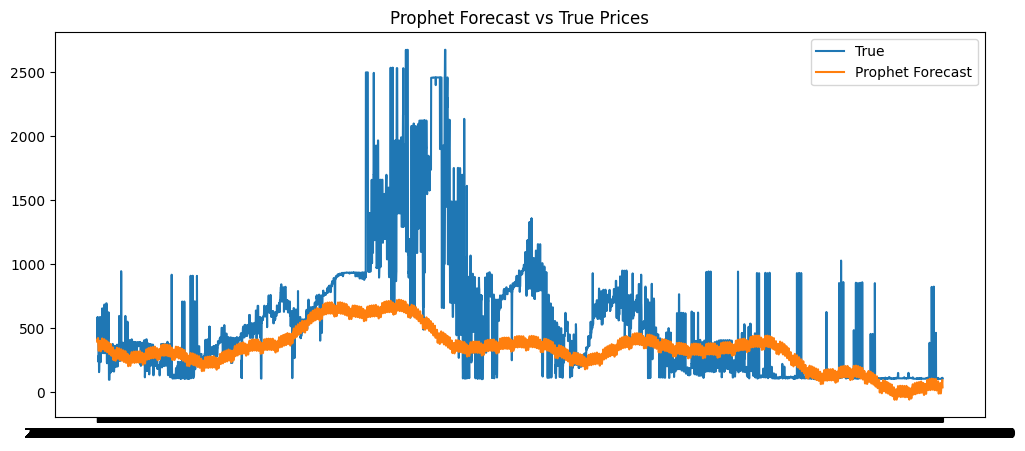

In [18]:
df_prophet = df_prophet.reset_index()[["FECHA_HORA", "PRECIO"]].rename(columns={"FECHA_HORA": "ds", "PRECIO": "y"})

# Train/test split: last 20% as test
train_size = int(len(df_prophet) * 0.8)
train_df, test_df = df_prophet.iloc[:train_size], df_prophet.iloc[train_size:]

# Fit Prophet model
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
prophet.fit(train_df)

# Forecast over test period
future = prophet.make_future_dataframe(periods=len(test_df), freq="h")
forecast = prophet.predict(future)

# Extract predictions only for test period
pred_prophet = forecast.set_index("ds").loc[test_df["ds"], "yhat"]

# Metrics
mae_p = mean_absolute_error(test_df["y"], pred_prophet)
rmse_p = mean_squared_error(test_df["y"], pred_prophet, squared=False)
r2 = r2_score(test_df["y"], pred_prophet)

print("Prophet Forecasting Results:")
print(f"MAE: {mae_p:.2f}, RMSE: {rmse_p:.2f}, R2: {r2:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(test_df["ds"], test_df["y"], label="True")
plt.plot(test_df["ds"], pred_prophet, label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast vs True Prices")
plt.show()

### Ensemble Prophet + XGBoost

C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


XGBoost with Prophet feature:
MAE: 252.50, RMSE: 444.74, R2: 0.21


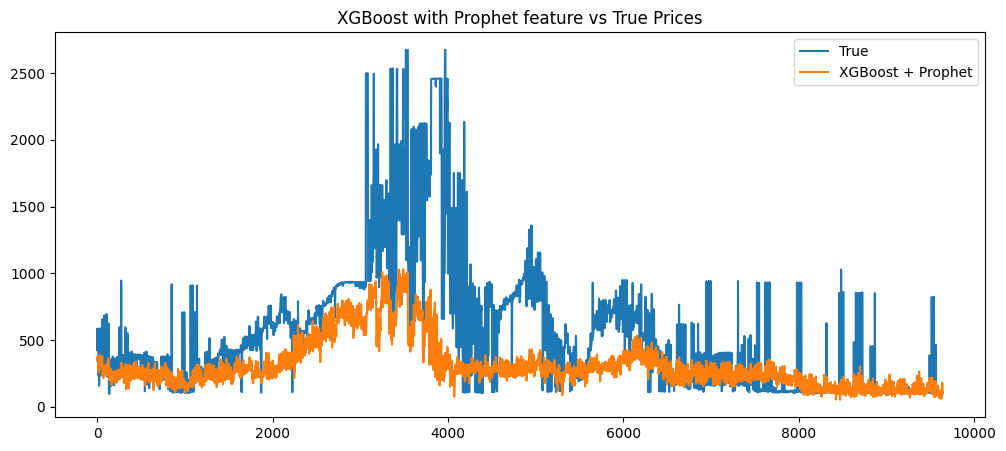

In [20]:
# --- Use Prophet as a feature for XGBoost ---

X_full = df.copy().drop(columns=["FECHA_HORA"])

# Add propehet prediction as a new column
X_full["prophet_yhat"] = forecast.set_index("ds")["yhat"].values

# Define train/test (temporal split)
X_train = X_full.iloc[:train_size].drop(columns=["PRECIO"])
y_train = X_full.iloc[:train_size]["PRECIO"]
X_test = X_full.iloc[train_size:].drop(columns=["PRECIO"])
y_test = X_full.iloc[train_size:]["PRECIO"]

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=500, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# --- Metrics ---
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = mean_squared_error(y_test, y_pred_xgb, squared=False)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost with Prophet feature:")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# --- Paso 5: Graficamos ---
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="True")
plt.plot(y_pred_xgb, label="XGBoost + Prophet")
plt.legend()
plt.title("XGBoost with Prophet feature vs True Prices")
plt.show()

## Train and test with lags

In [4]:
# --- Create lag features ---
def create_lags(df, target_col, n_lags=24):
    df_lagged = df.copy()
    for lag in range(1, n_lags+1):
        df_lagged[f"{target_col}_lag{lag}"] = df_lagged[target_col].shift(lag)
    return df_lagged.dropna()

df_lagged = create_lags(df, target_col="PRECIO", n_lags=24)
df_lagged = df_lagged.dropna()

# Features (all except date & target)
X = df_lagged.drop(columns=["FECHA_HORA", "PRECIO"])
y = df_lagged["PRECIO"]

# --- Train/Test split ---
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [22]:
X_train.head()

,YEAR,MONTH,DAY,HORA,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,...,PRECIO_lag15,PRECIO_lag16,PRECIO_lag17,PRECIO_lag18,PRECIO_lag19,PRECIO_lag20,PRECIO_lag21,PRECIO_lag22,PRECIO_lag23,PRECIO_lag24
24,2020,1,2,0,1608662.67,4585681.98,0.0,19184.34,4908.48,1.0,...,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71,72.02
25,2020,1,2,1,1508655.14,4466153.60,0.0,19342.06,3836.61,1.0,...,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71
26,2020,1,2,2,1413968.65,4520386.10,0.0,20345.52,5343.35,1.0,...,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71
27,2020,1,2,3,1369278.08,4470436.67,0.0,21123.41,3942.81,1.0,...,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71
28,2020,1,2,4,1353049.36,4558570.93,0.0,25773.80,2363.15,1.0,...,136.71,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71


### XGBoost Forecasting with Lags

C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


XGBoost Forecasting Results:
MAE: 91.66, RMSE: 254.90, R2: 0.74


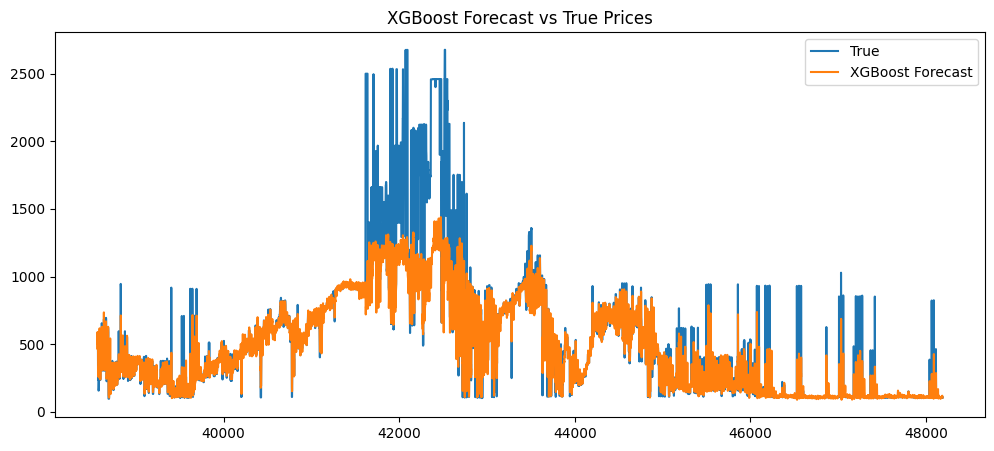

In [23]:
# ===========================================
# XGBoost Forecasting with Lags
# ===========================================

# Train XGBoost
model_xgb = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.1, max_depth=6)
model_xgb.fit(X_train, y_train)

# Predictions
pred_xgb = model_xgb.predict(X_test)

# Metrics
mae_x = mean_absolute_error(y_test, pred_xgb)
rmse_x = mean_squared_error(y_test, pred_xgb, squared=False)
r2_x = r2_score(y_test, pred_xgb)

print("XGBoost Forecasting Results:")
print(f"MAE: {mae_x:.2f}, RMSE: {rmse_x:.2f}, R2: {r2_x:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="True")
plt.plot(y_test.index, pred_xgb, label="XGBoost Forecast")
plt.legend()
plt.title("XGBoost Forecast vs True Prices")
plt.show()

### Boosting with lags

In [24]:
models = {
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
}

In [25]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

df_results = pd.DataFrame(results).T
print(df_results)

C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007777 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10015
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 48
[LightGBM] [Info] Start training from score 318.370624


C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


                MAE        RMSE        R2
XGBoost   92.709258  258.178276  0.734879
LightGBM  81.664990  225.921981  0.796988
CatBoost  81.851304  225.950991  0.796936


C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Boosting with lags (tunning)

In [26]:
# ===================== OBJECTIVES =====================

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }

    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return mean_squared_error(y_test, preds, squared=False)  # RMSE


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = LGBMRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return mean_squared_error(y_test, preds, squared=False)  # RMSE


def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1)
    }

    model = CatBoostRegressor(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return mean_squared_error(y_test, preds, squared=False)  # RMSE

In [27]:
# ===================== RUN STUDIES =====================

studies = {}
for name, objective in [("XGBoost", objective_xgb), 
                        ("LightGBM", objective_lgbm), 
                        ("CatBoost", objective_cat)]:
    print(f"Running Optuna for {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100)  # puedes subir n_trials si quieres
    studies[name] = study
    print(f"Best params for {name}: {study.best_trial.params}")
    print(f"Best RMSE: {study.best_value:.4f}\n")


# ===================== FINAL EVALUATION =====================

results = {}
best_params = {}
best_scores = {}

for name, study in studies.items():
    if name == "XGBoost":
        model = XGBRegressor(**study.best_trial.params, random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        model = LGBMRegressor(**study.best_trial.params, random_state=42)
    else:
        model = CatBoostRegressor(**study.best_trial.params, random_state=42, verbose=0)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    best_params[name] = study.best_trial.params
    best_scores[name] = study.best_value
    
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds, squared=False),
        "R2": r2_score(y_test, preds)
    }


[I 2025-08-20 11:05:08,138] A new study created in memory with name: no-name-9f0bea4a-fc92-4665-9475-2a27109cd4b1


Running Optuna for XGBoost...


C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
[I 2025-08-20 11:05:15,192] Trial 0 finished with value: 227.09838263018077 and parameters: {'n_estimators': 1435, 'learning_rate': 0.02761815221428465, 'max_depth': 3, 'subsample': 0.6141312065718418, 'colsample_bytree': 0.818469971789786, 'gamma': 4.473448934380542, 'reg_alpha': 4.343217719999736, 'reg_lambda': 4.980789908857289}. Best is trial 0 with value: 227.09838263018077.
C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
[I 2025-08-20 11:05:24,285] Trial 1 finished with value: 286.18

Best params for XGBoost: {'n_estimators': 346, 'learning_rate': 0.02692116497882991, 'max_depth': 3, 'subsample': 0.7425199895973245, 'colsample_bytree': 0.9609494468903915, 'gamma': 2.7586038842198803, 'reg_alpha': 1.547842626280357, 'reg_lambda': 2.598789504578664}
Best RMSE: 217.7344

Running Optuna for LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10015
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 48
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
[I 2025-08-20 11:15:29,456] Trial 0 finished with value: 217.62085928731346 and parameters: {'n_estimators': 247, 'learning_rate': 0.0466761558141506, 'num_leaves': 286, 'max_depth': 9, 'min_child_samples': 92, 'subsample': 0.867657219970778, 'colsample_bytree': 0.969374283911977}. Best is trial 0 with value: 217.62085928731346.


...

C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
[I 2025-08-20 11:30:12,333] Trial 0 finished with value: 228.12266974544934 and parameters: {'iterations': 236, 'learning_rate': 0.29259430628625815, 'depth': 4, 'l2_leaf_reg': 5.740033819409998, 'bagging_temperature': 0.7547771908664382}. Best is trial 0 with value: 228.12266974544934.
C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
[I 2025-08-20 11:34:09,933] Trial 1 finished with value: 256.9904630446569 and parameters: {'iterations': 512, 'learning_rate': 0.05543180162012662, 'depth': 

Best params for CatBoost: {'iterations': 1361, 'learning_rate': 0.03317531686499387, 'depth': 3, 'l2_leaf_reg': 9.241772890421714, 'bagging_temperature': 0.9499729230411113}
Best RMSE: 214.4572



C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007758 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10015
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 48
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Camilo\anaconda3\envs\env_IPA\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [28]:
params_df = pd.DataFrame(best_params).T
params_df["Best_RMSE"] = pd.Series(best_scores)
results_df = pd.DataFrame(results).T

print("\n===== Best Hyperparameters per Model =====")
print(params_df)
print(results_df)


===== Best Hyperparameters per Model =====
          n_estimators  learning_rate  max_depth  subsample  colsample_bytree  \
XGBoost          346.0       0.026921        3.0   0.742520          0.960949   
LightGBM         445.0       0.022434        3.0   0.609051          0.656274   
CatBoost           NaN       0.033175        NaN        NaN               NaN   

             gamma  reg_alpha  reg_lambda  num_leaves  min_child_samples  \
XGBoost   2.758604   1.547843     2.59879         NaN                NaN   
LightGBM       NaN        NaN         NaN        41.0               87.0   
CatBoost       NaN        NaN         NaN         NaN                NaN   

          iterations  depth  l2_leaf_reg  bagging_temperature   Best_RMSE  
XGBoost          NaN    NaN          NaN                  NaN  217.734395  
LightGBM         NaN    NaN          NaN                  NaN  213.045928  
CatBoost      1361.0    3.0     9.241773             0.949973  214.457223  
                MAE   

### Baseline models with lag

In [29]:
# Entrenar cada modelo base con cross-validation
results_base = {}

# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

for name, model in baseline_models.items():
    scores = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results_base[name] = {
        metric: np.mean(scores[f"test_{metric}"]) for metric in scoring.keys()
    }

# Mostrar resultados
results_base_df = pd.DataFrame(results_base).T
print(results_base_df)

                         r2         mae           mse        rmse
Linear Regression  0.948861   26.688284   4552.139249   55.639576
Ridge              0.948902   26.682088   4551.988939   55.634331
Lasso              0.949711   26.323077   4548.371318   55.489719
ElasticNet         0.949347   26.390689   4551.060019   55.541914
Decision Tree      0.604971   81.746917  43626.623003  164.769597
Random Forest      0.812593   57.368246  24220.246787  117.857533
Gradient Boosting  0.839483   51.623060  26092.362366  115.065550
SVR               -0.073152  180.865233  88066.217401  253.522755
KNN                0.106742  151.601034  67417.792315  223.951777


### Baseline models (linear) with lag (tunning)

In [30]:
# ========================
# Setting
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

# Scorers
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "rmse": make_scorer(lambda y, y_pred: mean_squared_error(y, y_pred, squared=False))
}

# ========================
# Linear models → GridSearchCV
# ========================

linear_grids = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso": (Lasso(max_iter=5000), {"alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "ElasticNet": (ElasticNet(max_iter=5000), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
}

In [31]:
results = {}

for name, (model, grid) in linear_grids.items():
    search = GridSearchCV(
        model,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1
    )
    search.fit(X, y)
    best_model = search.best_estimator_

    # Cross-validate with multiple metrics
    scores = cross_val_score(best_model, X, y, cv=tscv, scoring="r2")
    r2 = scores.mean()
    scores_mae = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
    mae = -scores_mae.mean()
    scores_rmse = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    rmse = -scores_rmse.mean()

    results[name] = {
        "Best Params": search.best_params_,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_results = pd.DataFrame(results).T
df_results

,Best Params,R2,MAE,RMSE
Linear Regression,{},0.948861,26.688284,55.639576
Ridge,{'alpha': 100},0.949168,26.595779,55.589767
Lasso,{'alpha': 0.1},0.949673,26.3468,55.473241
ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.9}",0.949626,26.345297,55.47959


In [32]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959

### Baseline models (non-linear) with lag (tunning)

In [5]:
# ========================
# Non-linear models → Optuna
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

def optuna_objective(trial, model_name):
    
    if model_name == "Decision Tree":
        model = DecisionTreeRegressor(
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            random_state=42
        )

    elif model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            n_jobs=-1, random_state=42
        )

    elif model_name == "Gradient Boosting":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 10),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            random_state=42
        )

    # CV RMSE
    scores = cross_val_score(model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    return -scores.mean()

In [6]:
nonlinear_models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

In [7]:
nonlinear_results = {}

for name in nonlinear_models:
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: optuna_objective(trial, name), n_trials=30, n_jobs=-1)

    best_params = study.best_params

    # Entrenar con los mejores parámetros
    if name == "Decision Tree":
        best_model = DecisionTreeRegressor(**best_params, random_state=42)
    elif name == "Random Forest":
        best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=42)
    elif name == "Gradient Boosting":
        best_model = GradientBoostingRegressor(**best_params, random_state=42)

    # Cross-validate with metrics
    r2 = cross_val_score(best_model, X, y, cv=tscv, scoring="r2").mean()
    mae = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error").mean()
    rmse = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error").mean()

    nonlinear_results[name] = {
        "Best Params": best_params,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_nonlinear_results = pd.DataFrame(nonlinear_results).T
df_nonlinear_results

[I 2025-08-21 10:22:07,230] A new study created in memory with name: no-name-e257f1eb-dc02-4034-b967-db40c6e02a50
[I 2025-08-21 10:22:11,580] Trial 15 finished with value: 153.23570973424938 and parameters: {'max_depth': 2, 'min_samples_split': 14}. Best is trial 15 with value: 153.23570973424938.
[I 2025-08-21 10:22:13,707] Trial 3 finished with value: 123.62691204575474 and parameters: {'max_depth': 3, 'min_samples_split': 18}. Best is trial 3 with value: 123.62691204575474.
[I 2025-08-21 10:22:15,468] Trial 2 finished with value: 101.28283532873782 and parameters: {'max_depth': 4, 'min_samples_split': 7}. Best is trial 2 with value: 101.28283532873782.
[I 2025-08-21 10:22:17,361] Trial 6 finished with value: 98.82814400209875 and parameters: {'max_depth': 5, 'min_samples_split': 17}. Best is trial 6 with value: 98.82814400209875.
[I 2025-08-21 10:22:17,493] Trial 16 finished with value: 98.82814400209875 and parameters: {'max_depth': 5, 'min_samples_split': 3}. Best is trial 6 with 

,Best Params,R2,MAE,RMSE
Decision Tree,"{'max_depth': 5, 'min_samples_split': 17}",0.852894,47.07064,98.828144
Random Forest,"{'n_estimators': 407, 'max_depth': 4, 'min_sam...",0.862698,47.776219,101.928488
Gradient Boosting,"{'n_estimators': 710, 'learning_rate': 0.00482...",0.851806,50.539166,103.066982


In [8]:
nonlinear_results

{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 17},
  'R2': 0.8528940981487452,
  'MAE': 47.07063996534437,
  'RMSE': 98.82814400209875},
 'Random Forest': {'Best Params': {'n_estimators': 407,
   'max_depth': 4,
   'min_samples_split': 16,
   'max_features': None},
  'R2': 0.8626976844486611,
  'MAE': 47.776218604543374,
  'RMSE': 101.92848807043003},
 'Gradient Boosting': {'Best Params': {'n_estimators': 710,
   'learning_rate': 0.004824184299163144,
   'max_depth': 2,
   'subsample': 0.54752888994856},
  'R2': 0.8518062305030419,
  'MAE': 50.53916588389959,
  'RMSE': 103.0669818471433}}

In [ ]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959
#Decision Tree	{'max_depth': 5, 'min_samples_split': 8}	0.852894	47.07064	98.828144
#Random Forest	{'n_estimators': 380, 'max_depth': 5, 'min_samples_split': 7,'max_features': None}	0.875931	44.651063	97.202218

In [ ]:
# Random forest
#{'Best Params': {'n_estimators': 380,
#  'max_depth': 5,
#  'min_samples_split': 7,
#  'max_features': None},
# 'R2': 0.8759310854350622,
# 'MAE': 44.6510629713005,
# 'RMSE': 97.20221800266624}

In [9]:
#{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 17},
#  'R2': 0.8528940981487452,
#  'MAE': 47.07063996534437,
#  'RMSE': 98.82814400209875},
# 'Random Forest': {'Best Params': {'n_estimators': 407,
#   'max_depth': 4,
#   'min_samples_split': 16,
#   'max_features': None},
#  'R2': 0.8626976844486611,
#  'MAE': 47.776218604543374,
#  'RMSE': 101.92848807043003},
# 'Gradient Boosting': {'Best Params': {'n_estimators': 710,
#   'learning_rate': 0.004824184299163144,
#   'max_depth': 2,
#   'subsample': 0.54752888994856},
#  'R2': 0.8518062305030419,
#  'MAE': 50.53916588389959,
#  'RMSE': 103.0669818471433}}

results 0 with value: 98.0681054649906.

### Other robust models

In [40]:
# Nuevos modelos robustos
new_models = {
    "Extra Trees": ExtraTreesRegressor(n_jobs=-1, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(random_state=42, max_iter=500)
}

In [41]:
# Evaluación
results_new = {}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

for name, model in new_models.items():
    pipe = Pipeline(steps=[("model", model)])
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results_new[name] = {metric: abs(scores[f"test_{metric}"].mean()) if metric != "r2"
                         else scores[f"test_{metric}"].mean()
                         for metric in scoring.keys()}

df_results_new = pd.DataFrame(results_new).T
print(df_results_new)

                                r2          mae           mse         rmse
Extra Trees               0.906150    37.084319  1.524159e+04    83.037984
Hist Gradient Boosting    0.905875    36.730164  1.233931e+04    80.835568
MLP Regressor          -237.929409  2312.511536  8.398510e+06  2688.093761


<hr>

## Long short-term memory (LSTM)

In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [55]:
# Numerical variables
print(numeric_features)

['TERMICA', 'HIDRAULICA', 'SOLAR', 'COGENERADOR', 'EOLICA', 'FUEL_CONS_ACPM', 'FUEL_CONS_CARBON', 'FUEL_CONS_COMBUSTOLEO', 'FUEL_CONS_CRUDO', 'FUEL_CONS_GAS', 'FUEL_CONS_GAS_NI', 'FUEL_CONS_GLP', 'FUEL_COST_CARBON', 'FUEL_COST_GAS', 'FUEL_COST_GAS_NI', 'FUEL_COST_COMBUSTOLEO', 'IPC_VAR_MOM_PCT', 'IPP_VAR_PN_MOM_PCT', 'IPP_VAR_OI_MOM_PCT']


In [66]:
# Scale numerical variables

# ============================
# 1. Prepare data
# ============================

scaler = MinMaxScaler()
df_scaled = df.copy().drop(columns=["FECHA_HORA"])
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])
df_scaled

,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020,1,1,0,72.02,0.363247,0.269862,0.000000,0.189648,0.100633,...,0.419581,0.000000,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597
1,2020,1,1,1,136.71,0.310187,0.286300,0.000000,0.191136,0.082356,...,0.419581,0.000000,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597
2,2020,1,1,2,127.71,0.278933,0.283414,0.000000,0.170337,0.061953,...,0.419581,0.000000,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597
3,2020,1,1,3,127.71,0.263346,0.274959,0.000000,0.168444,0.071108,...,0.419581,0.000000,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597
4,2020,1,1,4,127.71,0.276951,0.252457,0.000000,0.165776,0.058972,...,0.419581,0.000000,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025,6,30,19,112.55,0.190143,0.849097,0.001340,0.578630,0.547735,...,0.059990,0.316984,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791
48188,2025,6,30,20,112.55,0.191153,0.826843,0.000839,0.613528,0.549004,...,0.059990,0.316984,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791
48189,2025,6,30,21,106.25,0.204237,0.784387,0.000000,0.624925,0.546028,...,0.059990,0.316984,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791
48190,2025,6,30,22,105.55,0.209577,0.727481,0.000000,0.651119,0.546691,...,0.059990,0.316984,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791


In [95]:
# ============================
# 2. Create sequences for LSTM
# ============================

def create_sequences(data, target_col="PRECIO", window_size=24):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:(i + window_size)].values)
        y.append(data.iloc[i + window_size, target_idx])
    
    return np.array(X), np.array(y)

look_back = 48  # last 24 hours
X, y = create_sequences(df_scaled, target_col="PRECIO", window_size=look_back)

print("X shape:", X.shape)  # (samples, timesteps, features)
print("y shape:", y.shape)

X shape: (48144, 48, 25)
y shape: (48144,)


In [96]:
# ============================
# 3. Train-Test split (time series, not random)
# ============================
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [97]:
# ============================
# 4. Model construction (Multivariate - Single step)
# ============================

n_features = X_train.shape[2]  # Número total de variables predictoras

model = Sequential()
model.add(LSTM(128, activation='tanh', return_sequences=True, input_shape=(look_back, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # salida para regresión

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping (para evitar sobreentrenamiento)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_22 (LSTM)              (None, 48, 128)           78848     
                                                                 
 dropout_20 (Dropout)        (None, 48, 128)           0         
                                                                 
 lstm_23 (LSTM)              (None, 64)                49408     
                                                                 
 dropout_21 (Dropout)        (None, 64)                0         
                                                                 
 dense_19 (Dense)            (None, 32)                2080      
                                                                 
 dense_20 (Dense)            (None, 1)                 33        
                                                                 
Total params: 130369 (509.25 KB)
Trainable params: 13

In [98]:
# ============================
# 5. Train model

# ============================

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
482/482 [==============================] - 93s 180ms/step - loss: 41635.2656 - mae: 147.7719 - val_loss: 257692.9062 - val_mae: 428.2278
Epoch 2/50
482/482 [==============================] - 85s 177ms/step - loss: 14568.5947 - mae: 80.0882 - val_loss: 133694.4844 - val_mae: 281.2132
Epoch 3/50
482/482 [==============================] - 81s 168ms/step - loss: 8494.2432 - mae: 62.5363 - val_loss: 78953.1016 - val_mae: 204.6463
Epoch 4/50
482/482 [==============================] - 80s 165ms/step - loss: 5318.7793 - mae: 50.4465 - val_loss: 84368.3828 - val_mae: 205.3335
Epoch 5/50
482/482 [==============================] - 84s 174ms/step - loss: 5371.3022 - mae: 49.9849 - val_loss: 67471.0547 - val_mae: 185.1696
Epoch 6/50
482/482 [==============================] - 82s 170ms/step - loss: 4146.1040 - mae: 43.3885 - val_loss: 51585.5156 - val_mae: 157.1661
Epoch 7/50
482/482 [==============================] - 78s 162ms/step - loss: 3420.5818 - mae: 39.5801 - val_loss: 46174.6875 

In [99]:

# ============================
# 6. Evaluation
# ============================

y_pred = model.predict(X_test)

y_test_inv = y_test
y_pred_inv = y_pred.flatten()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"R2: {r2}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

301/301 [==============================] - 12s 36ms/step
R2: 0.2510065796773061, RMSE: 434.0590, MAE: 169.6595


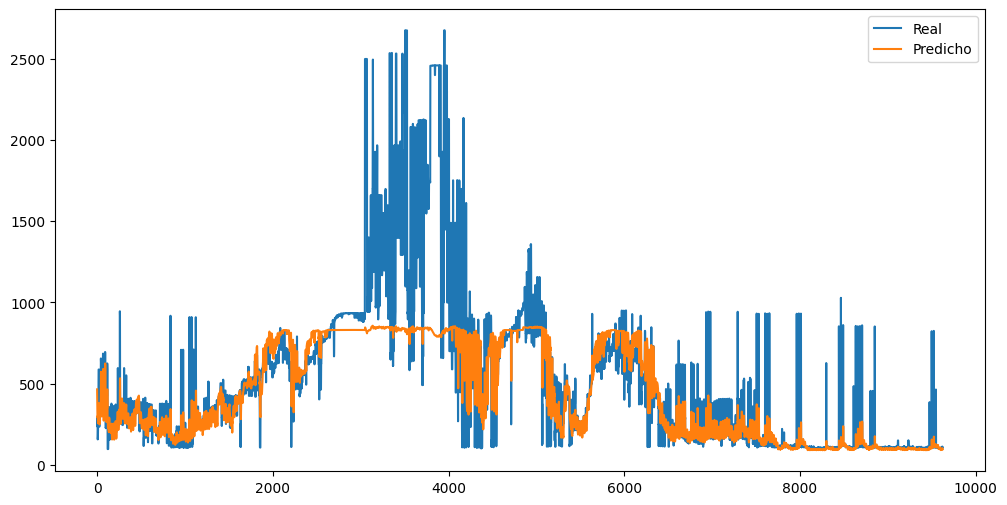

In [74]:
# ============================
# 7. Graphic
# ============================

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.legend()
plt.show()